# Vežbe 5: Logistička regresija nad slikama pomoću biblioteke PyTorch

U ovom notebook-u fokus je na **logističkoj regresiji** nad skupom slika **MNIST**.

Cilj je da kroz ovaj primer prikažemo:
- rad sa skupom slika,
- pripremu podataka za model,
- definisanje modela logističke regresije u biblioteci `PyTorch`,
- mini-batch treniranje pomoću `DataLoader` klase,
- evaluaciju modela,
- prikaz matrice konfuzije i osnovnih metrika klasifikacije.

In [1]:
# Import potrebnih biblioteka

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## 1. Postavljanje seed-a za reproduktivnost rezultata


In [2]:
# Postaviti seed za PyTorch

torch.manual_seed(42)

## 2. Učitavanje skupa podataka

In [3]:
# Učitati trening i test skup MNIST podataka

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.25MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]


In [4]:
# Prikazati broj slika u trening i test skupu

print("Broj slika u trening skupu:", len(train_dataset))
print("Broj slika u test skupu:", len(test_dataset))

Broj slika u trening skupu: 60000
Broj slika u test skupu: 10000


In [5]:
print(type(train_dataset))

<class 'torchvision.datasets.mnist.MNIST'>


In [6]:
# Uzeti prvu sliku iz trening skupa i prikazati:
# 1) tip podatka
# 2) dimenzije slike

print(type(train_dataset[0]))

print("Tip podatka prve slike:", train_dataset[0][0].type())
print("Dimenzije prve slike:", train_dataset[0][0].size())

<class 'tuple'>
Tip podatka prve slike: torch.FloatTensor
Dimenzije prve slike: torch.Size([1, 28, 28])


In [7]:
print(train_dataset[0][0])

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [8]:
# Prikazati labele za prve dve slike

print("Label prve slike:", train_dataset[0][1])
print("Label druge slike:", train_dataset[1][1])

Label prve slike: 5
Label druge slike: 0


## 3. Prikaz nekoliko primera iz skupa podataka


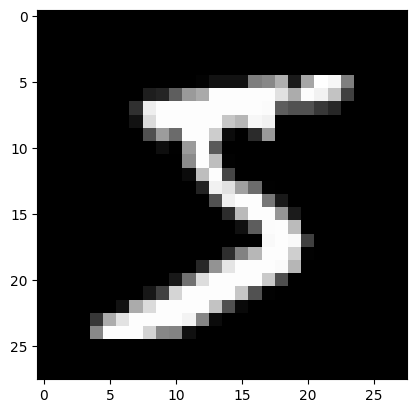

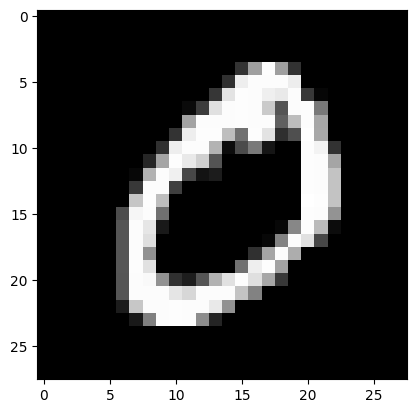

In [9]:
# Prikazati prve dve slike iz trening skupa

img_5 = train_dataset[0][0]
img_0 = train_dataset[1][0]

plt.imshow(img_5.squeeze(), cmap="gray")
plt.show()

plt.imshow(img_0.squeeze(), cmap="gray")
plt.show()

## 4. Kreiranje batch-eva pomoću DataLoader-a

In [10]:
# Formirati DataLoader objekte za trening i test skup.
# Koristiti batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Broj batch-eva u trening skupu:", len(train_loader))
print("Broj batch-eva u test skupu:", len(test_loader))


Broj batch-eva u trening skupu: 1875
Broj batch-eva u test skupu: 313


## 5. Definisanje modela


In [14]:
# Definisati klasu neuronske mreže za logističku regresiju

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.linear(x)

## 6. Kreiranje instance modela

In [15]:
# Definisati dimenzije ulaza i izlaza i kreirati instancu modela

input_dim = 28 * 28
output_dim = 10

model = LogisticRegressionModel(input_dim, output_dim)
print(model)

LogisticRegressionModel(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


## 7. Definisanje funkcije greške i optimizacionog algoritma

In [16]:
# Definisati funkciju greške CrossEntropy i SGD optimizacioni algoritam

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 8. Trening modela


In [17]:
# Istrenirati model i čuvati prosečnu grešku po epohi

num_epochs = 10

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for images, labels in train_loader:
        images = images.reshape(images.shape[0], -1)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)

    print(f"Epoha: {epoch + 1}, prosečna greška: {avg_epoch_loss:.4f}")


Epoha: 1, prosečna greška: 0.7686
Epoha: 2, prosečna greška: 0.4524
Epoha: 3, prosečna greška: 0.4007
Epoha: 4, prosečna greška: 0.3747
Epoha: 5, prosečna greška: 0.3584
Epoha: 6, prosečna greška: 0.3467
Epoha: 7, prosečna greška: 0.3378
Epoha: 8, prosečna greška: 0.3309
Epoha: 9, prosečna greška: 0.3251
Epoha: 10, prosečna greška: 0.3203


## 9. Predikcije modela

In [18]:
# Izračunati predikcije modela nad test skupom i sačuvati stvarne i predikovane klase.

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.reshape(images.shape[0], -1)
        outputs = model(images)

        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Broj predikcija:", len(all_preds))


Broj predikcija: 10000


## 10. Matrica konfuzije

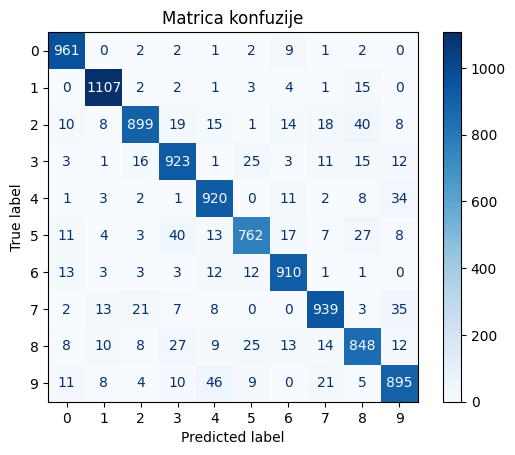

In [19]:
# Izračunati i prikazati matricu konfuzije

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matrica konfuzije")
plt.show()

## 11. Evaluacija modela

In [20]:
# Izračunati accuracy i classification report

accuracy = accuracy_score(all_labels, all_preds)
print("Tačnost modela:", round(accuracy, 4))

print("\nClassification report:")
print(classification_report(all_labels, all_preds))


Tačnost modela: 0.9164

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.94      0.87      0.90      1032
           3       0.89      0.91      0.90      1010
           4       0.90      0.94      0.92       982
           5       0.91      0.85      0.88       892
           6       0.93      0.95      0.94       958
           7       0.93      0.91      0.92      1028
           8       0.88      0.87      0.88       974
           9       0.89      0.89      0.89      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

